# E0B -- Validez de la aportación (WINNER_MODEL vs. Cong et al. genérica)

**Objetivo**: comparar `WINNER_MODEL` (el candidato que ganó E0A) contra
`qcnn_cong` -- la QCNN genérica de referencia (SU4 + Pooling_ansatz1 +
AngleEmbedding, sin sesgo de diseño de ningún paper específico), mismo
protocolo y criterio estadístico que E0A/E0_quantum_advantage.

**Pregunta que responde**: ¿la aportación específica de `WINNER_MODEL`
(encoding denso de Hur, filtro LCU de Wei, o tree-hybrid encoding de Gong)
se traduce en una ventaja real sobre una QCNN jerárquica genérica, o el
desempeño observado en E0A se explica solo por tener una arquitectura QCNN
razonable en general?

**Nota sobre significancia**: igual que en `E0_quantum_advantage.ipynb`,
con n=5 semillas se reporta también el solape de IC bootstrap BCa como
evidencia complementaria desde el inicio.

**Esta fase NO decide nada por sí sola** -- termina con evidencia (Sec. 8) y
dos variables para que TÚ decidas manualmente si `cong` entra a E1/E2 (ver
la celda de handoff al final).


In [1]:
import json
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qcnn_benchmark.config import load_config
from qcnn_benchmark.data import load_mnist_pool, load_fashion_mnist_pool
from qcnn_benchmark.representations import build_pca_dataset, build_amplitude_dataset
from qcnn_benchmark.models import qcnn_hur, qcnn_wei, qcnn_gong, qcnn_cong
from qcnn_benchmark.training import train_binary_classifier, uniform_pi_init, normal_init
from qcnn_benchmark.metrics import batch_accuracy
from qcnn_benchmark.stats import (
    bootstrap_bca_ci,
    paired_sign_permutation_test,
    holm_correction,
    cohens_dz,
    probability_of_superiority,
)


## 0. INPUTS MANUALES -- completar antes de correr

`WINNER_MODEL`: el mismo valor que usaste en `E0_quantum_advantage.ipynb`
(el que imprimió la Sec. 10 de `E0A_seleccion_candidato.ipynb`).


In [2]:
WINNER_MODEL = 'wei'  # <-- mismo valor que en E0_quantum_advantage.ipynb
assert WINNER_MODEL in ("hur", "wei", "gong"), "Completa WINNER_MODEL arriba"
print("WINNER_MODEL:", WINNER_MODEL, " vs. cong")


WINNER_MODEL: wei  vs. cong


## 1. Configuración declarativa

In [3]:
FAST_SMOKE_TEST = False  # True = 2 semillas, pocas actualizaciones, solo para validar el pipeline

_CONFIG_CANDIDATES = [pathlib.Path("configs/e0b.yaml"), pathlib.Path("../configs/e0b.yaml")]
CONFIG_PATH = next(p for p in _CONFIG_CANDIDATES if p.exists())
config = load_config(CONFIG_PATH)

config = config.model_copy(update={"models": [WINNER_MODEL, "cong"]})

if FAST_SMOKE_TEST:
    config = config.model_copy(update={
        "n_seeds": 2,
        "protocol": config.protocol.model_copy(update={"n_updates": 10, "val_check_every": 5, "patience_checks": 2}),
    })

print("experiment_id:", config.experiment_id)
print("canonical_hash:", config.canonical_hash(), "(FAST_SMOKE_TEST)" if FAST_SMOKE_TEST else "")
print("datasets:", [d.name for d in config.datasets])
print("models:", config.models)
print("run_seeds:", config.run_seeds())


experiment_id: E0B
canonical_hash: aad70cb6df8c 
datasets: ['coat_vs_shirt', '4_vs_9', '1_vs_0']
models: ['wei', 'cong']
run_seeds: [0, 1, 2, 3, 4]


## 2. Registro de modelos y representaciones

In [4]:
MODEL_REGISTRY = {
    "hur": {"module": qcnn_hur, "init": uniform_pi_init, "normalize": True,
            "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=16, verbose=False)},
    "wei": {"module": qcnn_wei, "init": normal_init, "normalize": False,
            "build_rep": lambda x, y, pos, neg: build_amplitude_dataset(x, y, pos, neg, verbose=False)},
    "gong": {"module": qcnn_gong, "init": uniform_pi_init, "normalize": True,
             "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=8, verbose=False)},
    "cong": {"module": qcnn_cong, "init": uniform_pi_init, "normalize": True,
             "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=8, verbose=False)},
}

_POOL_CACHE = {}


def get_pool(source, normalize):
    key = (source, normalize)
    if key not in _POOL_CACHE:
        loader = load_mnist_pool if source == "mnist" else load_fashion_mnist_pool
        _POOL_CACHE[key] = loader(normalize=normalize)
    return _POOL_CACHE[key]


## 3. Ejecución (matriz: datasets × {WINNER_MODEL, cong} × semillas)

In [5]:
RESULTS_DIR = pathlib.Path("results") if pathlib.Path("results").exists() else pathlib.Path("../results")
raw_path = RESULTS_DIR / f"e0b_raw_{config.canonical_hash()}.csv"

rows = []
t_start = time.time()
for dataset in config.datasets:
    for model_name in config.models:
        entry = MODEL_REGISTRY[model_name]
        x_all, y_all = get_pool(dataset.source, entry["normalize"])
        rep = entry["build_rep"](x_all, y_all, dataset.class_pos, dataset.class_neg)

        for seed in config.run_seeds():
            tag = f"{dataset.name}-{model_name}-seed{seed}"
            result = train_binary_classifier(
                entry["module"].predict_proba, entry["module"].TOTAL_PARAMS, rep, entry["init"],
                run_seed=seed,
                batch_size=config.protocol.batch_size,
                n_updates=config.protocol.n_updates,
                learning_rate=config.protocol.learning_rate,
                beta1=config.protocol.beta1,
                beta2=config.protocol.beta2,
                clip_norm=config.protocol.clip_norm,
                val_check_every=config.protocol.val_check_every,
                patience_checks=config.protocol.patience_checks,
                min_delta=config.protocol.min_delta,
                verbose=False,
                tag=tag,
            )
            train_acc = batch_accuracy(entry["module"].predict_proba, result["params"], rep["X_train"], rep["y_train"])
            test_acc = batch_accuracy(entry["module"].predict_proba, result["params"], rep["X_test"], rep["y_test"])
            rows.append({
                "dataset": dataset.name, "model": model_name, "seed": seed,
                "train_acc": train_acc, "test_acc": test_acc,
                "n_updates_run": result["n_updates_run"], "stopped_early_at": result["stopped_early_at"],
                "best_val_loss": result["best_val_loss"],
            })
            print(f"[{tag}] test_acc={test_acc:.4f}  (t={time.time()-t_start:.0f}s acumulado)")

            raw_df = pd.DataFrame(rows)
            raw_df.to_csv(raw_path, index=False)

print("Total:", time.time() - t_start, "s")
raw_df = pd.DataFrame(rows)
raw_df


[coat_vs_shirt-wei-seed0] test_acc=0.7720  (t=409s acumulado)
[coat_vs_shirt-wei-seed1] test_acc=0.7750  (t=815s acumulado)
[coat_vs_shirt-wei-seed2] test_acc=0.7700  (t=1180s acumulado)
[coat_vs_shirt-wei-seed3] test_acc=0.7740  (t=1586s acumulado)
[coat_vs_shirt-wei-seed4] test_acc=0.7640  (t=1992s acumulado)
[coat_vs_shirt-cong-seed0] test_acc=0.7060  (t=3078s acumulado)
[coat_vs_shirt-cong-seed1] test_acc=0.7610  (t=4440s acumulado)
[coat_vs_shirt-cong-seed2] test_acc=0.7420  (t=5693s acumulado)
[coat_vs_shirt-cong-seed3] test_acc=0.7260  (t=7028s acumulado)
[coat_vs_shirt-cong-seed4] test_acc=0.7470  (t=7946s acumulado)
[4_vs_9-wei-seed0] test_acc=0.9580  (t=8354s acumulado)
[4_vs_9-wei-seed1] test_acc=0.9590  (t=8759s acumulado)
[4_vs_9-wei-seed2] test_acc=0.9440  (t=9029s acumulado)
[4_vs_9-wei-seed3] test_acc=0.9550  (t=9433s acumulado)
[4_vs_9-wei-seed4] test_acc=0.9530  (t=9841s acumulado)
[4_vs_9-cong-seed0] test_acc=0.7800  (t=11040s acumulado)
[4_vs_9-cong-seed1] test_acc=

,dataset,model,seed,train_acc,test_acc,n_updates_run,stopped_early_at,best_val_loss
0,coat_vs_shirt,wei,0,0.747,0.772,500,NaN,0.526474
1,coat_vs_shirt,wei,1,0.782,0.775,500,NaN,0.516676
2,coat_vs_shirt,wei,2,0.744,0.770,450,450.0,0.533624
3,coat_vs_shirt,wei,3,0.774,0.774,500,NaN,0.514200
4,coat_vs_shirt,wei,4,0.771,0.764,500,NaN,0.482949
5,coat_vs_shirt,cong,0,0.704,0.706,380,380.0,0.610645
6,coat_vs_shirt,cong,1,0.756,0.761,480,480.0,0.572072
7,coat_vs_shirt,cong,2,0.758,0.742,440,440.0,0.604606
8,coat_vs_shirt,cong,3,0.722,0.726,470,470.0,0.602696
9,coat_vs_shirt,cong,4,0.747,0.747,320,320.0,0.564757


## 4. Resultados crudos

In [6]:
raw_df = pd.read_csv(raw_path)
display(raw_df)
raw_df.pivot_table(index="dataset", columns="model", values="test_acc", aggfunc=list)


,dataset,model,seed,train_acc,test_acc,n_updates_run,stopped_early_at,best_val_loss
0,coat_vs_shirt,wei,0,0.747,0.772,500,NaN,0.526474
1,coat_vs_shirt,wei,1,0.782,0.775,500,NaN,0.516676
2,coat_vs_shirt,wei,2,0.744,0.770,450,450.0,0.533624
3,coat_vs_shirt,wei,3,0.774,0.774,500,NaN,0.514200
4,coat_vs_shirt,wei,4,0.771,0.764,500,NaN,0.482949
5,coat_vs_shirt,cong,0,0.704,0.706,380,380.0,0.610645
6,coat_vs_shirt,cong,1,0.756,0.761,480,480.0,0.572072
7,coat_vs_shirt,cong,2,0.758,0.742,440,440.0,0.604606
8,coat_vs_shirt,cong,3,0.722,0.726,470,470.0,0.602696
9,coat_vs_shirt,cong,4,0.747,0.747,320,320.0,0.564757


model,cong,wei
dataset,,
1_vs_0,"[0.983, 0.988, 0.988, 0.99, 0.988]","[0.995, 0.993, 0.988, 0.994, 0.992]"
4_vs_9,"[0.78, 0.876, 0.876, 0.803, 0.866]","[0.958, 0.959, 0.944, 0.955, 0.953]"
coat_vs_shirt,"[0.706, 0.761, 0.742, 0.726, 0.747]","[0.772, 0.775, 0.77, 0.774, 0.764]"


## 5. Métricas agregadas (media ± IC bootstrap BCa por dataset)

In [7]:
agg_rows = []
for (dataset_name, model_name), group in raw_df.groupby(["dataset", "model"]):
    accs = group["test_acc"].to_numpy()
    lo, hi = bootstrap_bca_ci(
        accs, n_bootstrap=config.statistical_criterion.n_bootstrap,
        confidence_level=config.statistical_criterion.confidence_level,
        rng=np.random.default_rng(0),
    )
    agg_rows.append({
        "dataset": dataset_name, "model": model_name,
        "mean_test_acc": float(np.mean(accs)), "ci_lo": lo, "ci_hi": hi, "n_seeds": len(accs),
    })

agg_df = pd.DataFrame(agg_rows)
agg_df


,dataset,model,mean_test_acc,ci_lo,ci_hi,n_seeds
0,1_vs_0,cong,0.9874,0.984000,0.9888,5
1,1_vs_0,wei,0.9924,0.989600,0.9940,5
2,4_vs_9,cong,0.8402,0.798749,0.8720,5
3,4_vs_9,wei,0.9538,0.947600,0.9574,5
4,coat_vs_shirt,cong,0.7364,0.718000,0.7512,5
5,coat_vs_shirt,wei,0.7710,0.766800,0.7736,5


## 6. Análisis estadístico (permutación pareada + Holm, tamaños de efecto, solape de IC)

In [8]:
from itertools import combinations

comparison_rows = []
for dataset_name, group in raw_df.groupby("dataset"):
    pivot = group.pivot(index="seed", columns="model", values="test_acc")
    agg_lookup = agg_df[agg_df["dataset"] == dataset_name].set_index("model")
    for model_a, model_b in combinations(config.models, 2):
        x, y = pivot[model_a].to_numpy(), pivot[model_b].to_numpy()
        p_value, mean_diff = paired_sign_permutation_test(
            x, y, n_permutations=config.statistical_criterion.n_bootstrap,
            rng=np.random.default_rng(0),
        )
        lo_a, hi_a = agg_lookup.loc[model_a, ["ci_lo", "ci_hi"]]
        lo_b, hi_b = agg_lookup.loc[model_b, ["ci_lo", "ci_hi"]]
        ci_overlap = (lo_a <= hi_b) and (lo_b <= hi_a)
        comparison_rows.append({
            "dataset": dataset_name, "model_a": model_a, "model_b": model_b,
            "mean_diff_a_minus_b": mean_diff, "p_value": p_value,
            "cohens_dz": cohens_dz(x, y), "prob_superiority_a_over_b": probability_of_superiority(x, y),
            "ci_overlap": bool(ci_overlap),
        })

comparisons_df = pd.DataFrame(comparison_rows)
adjusted, rejected = holm_correction(comparisons_df["p_value"], alpha=config.statistical_criterion.alpha)
comparisons_df["p_value_holm"] = adjusted
comparisons_df["significant"] = rejected
comparisons_df


,dataset,model_a,model_b,mean_diff_a_minus_b,p_value,cohens_dz,prob_superiority_a_over_b,ci_overlap,p_value_holm,significant
0,1_vs_0,wei,cong,0.0050,0.1250,1.147079,0.9,False,0.1875,False
1,4_vs_9,wei,cong,0.1136,0.0625,2.350250,1.0,False,0.1875,False
2,coat_vs_shirt,wei,cong,0.0346,0.0625,1.569811,1.0,False,0.1875,False


## 7. Figuras y tablas

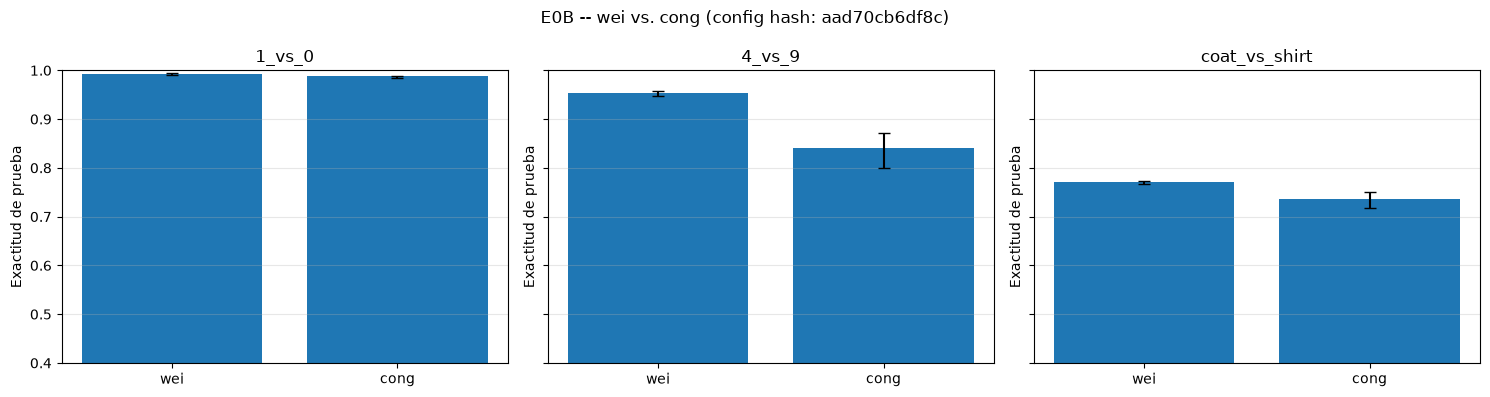

In [9]:
fig, axes = plt.subplots(1, len(config.datasets), figsize=(5 * len(config.datasets), 4), sharey=True)
if len(config.datasets) == 1:
    axes = [axes]
for ax, (dataset_name, group) in zip(axes, agg_df.groupby("dataset")):
    group = group.set_index("model").loc[config.models]
    yerr = [group["mean_test_acc"] - group["ci_lo"], group["ci_hi"] - group["mean_test_acc"]]
    ax.bar(group.index, group["mean_test_acc"], yerr=yerr, capsize=4)
    ax.set_title(dataset_name)
    ax.set_ylabel("Exactitud de prueba")
    ax.set_ylim(0.4, 1.0)
    ax.grid(alpha=0.3, axis="y")
plt.suptitle(f"E0B -- {WINNER_MODEL} vs. cong (config hash: " + config.canonical_hash() + ")")
plt.tight_layout()
plt.show()


In [10]:
display(comparisons_df.style.format({
    "mean_diff_a_minus_b": "{:+.4f}", "p_value": "{:.4f}", "p_value_holm": "{:.4f}",
    "cohens_dz": "{:.2f}", "prob_superiority_a_over_b": "{:.2f}",
}))


,dataset,model_a,model_b,mean_diff_a_minus_b,p_value,cohens_dz,prob_superiority_a_over_b,ci_overlap,p_value_holm,significant
0,1_vs_0,wei,cong,+0.0050,0.1250,1.15,0.90,False,0.1875,False
1,4_vs_9,wei,cong,+0.1136,0.0625,2.35,1.00,False,0.1875,False
2,coat_vs_shirt,wei,cong,+0.0346,0.0625,1.57,1.00,False,0.1875,False


## 8. Evidencia -- ¿supera WINNER_MODEL a la QCNN genérica de Cong?

In [11]:
alpha = config.statistical_criterion.alpha
print(f"{WINNER_MODEL} vs. cong -- alpha={alpha}\n")

n_datasets_winner_beats_cong = 0
for dataset_name, group in agg_df.groupby("dataset"):
    ranked = group.sort_values("mean_test_acc", ascending=False).reset_index(drop=True)
    winner, runner_up = ranked.loc[0, "model"], ranked.loc[1, "model"]
    if winner == WINNER_MODEL:
        n_datasets_winner_beats_cong += 1
    row = comparisons_df[
        (comparisons_df["dataset"] == dataset_name)
        & (comparisons_df[["model_a", "model_b"]].isin([winner, runner_up]).all(axis=1))
    ]
    is_significant = bool(row["significant"].iloc[0]) if len(row) else None
    ci_overlap = bool(row["ci_overlap"].iloc[0]) if len(row) else None
    print(f"{dataset_name}: gana {winner} ({ranked.loc[0, 'mean_test_acc']:.4f}) "
          f"sobre {runner_up} ({ranked.loc[1, 'mean_test_acc']:.4f}) -- "
          f"{'significativo' if is_significant else 'NO significativo'} tras Holm, "
          f"IC {'se solapan' if ci_overlap else 'NO se solapan'}")

print(f"\n{WINNER_MODEL} gana en media en {n_datasets_winner_beats_cong}/{len(config.datasets)} datasets frente a cong.")


wei vs. cong -- alpha=0.05

1_vs_0: gana wei (0.9924) sobre cong (0.9874) -- NO significativo tras Holm, IC NO se solapan
4_vs_9: gana wei (0.9538) sobre cong (0.8402) -- NO significativo tras Holm, IC NO se solapan
coat_vs_shirt: gana wei (0.7710) sobre cong (0.7364) -- NO significativo tras Holm, IC NO se solapan

wei gana en media en 3/3 datasets frente a cong.


## 9. Registro de reproducibilidad

In [12]:
import pennylane, sklearn, scipy

provenance = {
    "experiment_id": config.experiment_id,
    "winner_model": WINNER_MODEL,
    "canonical_hash": config.canonical_hash(),
    "config": json.loads(config.canonical_json()),
    "fast_smoke_test": FAST_SMOKE_TEST,
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "raw_results_path": str(raw_path),
    "package_versions": {
        "pennylane": pennylane.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
    },
}

provenance_path = RESULTS_DIR / f"e0b_provenance_{config.canonical_hash()}.json"
provenance_path.write_text(json.dumps(provenance, indent=2, ensure_ascii=False))
print("Provenance guardado en:", provenance_path)
print(json.dumps(provenance, indent=2, ensure_ascii=False))


Provenance guardado en: ../results/e0b_provenance_aad70cb6df8c.json
{
  "experiment_id": "E0B",
  "winner_model": "wei",
  "canonical_hash": "aad70cb6df8c",
  "config": {
    "datasets": [
      {
        "class_neg": 6,
        "class_pos": 4,
        "name": "coat_vs_shirt",
        "source": "fashion_mnist"
      },
      {
        "class_neg": 9,
        "class_pos": 4,
        "name": "4_vs_9",
        "source": "mnist"
      },
      {
        "class_neg": 0,
        "class_pos": 1,
        "name": "1_vs_0",
        "source": "mnist"
      }
    ],
    "description": "¿WINNER_MODEL (Hur, Wei o Gong, el que haya ganado E0A) supera a la QCNN genérica de Cong et al. (SU4 + Pooling_ansatz1 + AngleEmbedding, sin sesgo de diseño de ningún paper específico)? Este es el sub-experimento de \"validez de la aportación\": si WINNER_MODEL no supera a Cong de forma consistente, la aportación específica de su paper (encoding denso, filtro LCU, encoding tree-hybrid) no se estaría traduciendo en 

/var/folders/l9/hx3k3fcs03d6gz71m2n3t1c80000gn/T/ipykernel_25904/2314099716.py:9: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "timestamp_utc": pd.Timestamp.utcnow().isoformat(),


## 10. Handoff -- decide manualmente si Cong entra a E1/E2

In [13]:
print("=" * 78)
print("Con base en este resultado, decide manualmente:")
print()
print("  INCLUDE_CONG_IN_E1_E2 = True   # si quieres seguir midiendo a cong bajo")
print("                                  # shots finitos y ruido junto con WINNER_MODEL")
print("  INCLUDE_CONG_IN_E1_E2 = False  # si con esta evidencia ya alcanza para excluirlo")
print()
print("e introduce ese valor en E1_finite_shots.ipynb y E2_nisq_noise.ipynb.")
print("Este notebook NO decide ese booleano por ti -- solo te da la evidencia de arriba.")
print("=" * 78)


Con base en este resultado, decide manualmente:

  INCLUDE_CONG_IN_E1_E2 = True   # si quieres seguir midiendo a cong bajo
                                  # shots finitos y ruido junto con WINNER_MODEL
  INCLUDE_CONG_IN_E1_E2 = False  # si con esta evidencia ya alcanza para excluirlo

e introduce ese valor en E1_finite_shots.ipynb y E2_nisq_noise.ipynb.
Este notebook NO decide ese booleano por ti -- solo te da la evidencia de arriba.
